In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('../data/raw/application_train.csv')

In [12]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
L,C = df.shape
print(f"Le DataFrame contient {L} ligne(s) et {C} colonne(s)")

Le DataFrame contient 307511 ligne(s) et 122 colonne(s)


In [14]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [15]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

- Classe rembourssement = 0
- Classe Non rembourssement = 1

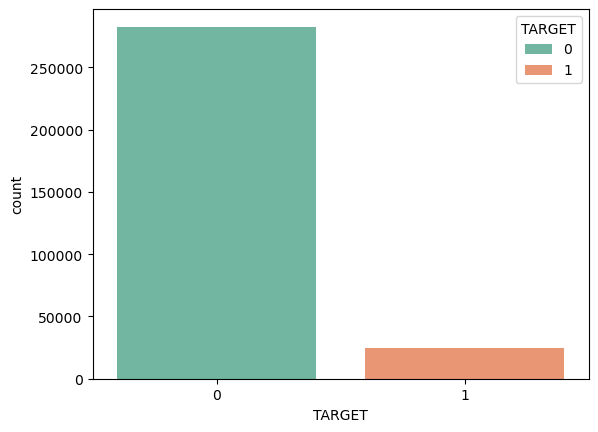

In [17]:
sns.countplot(data = df , x='TARGET', hue ='TARGET',palette='Set2')
plt.show()

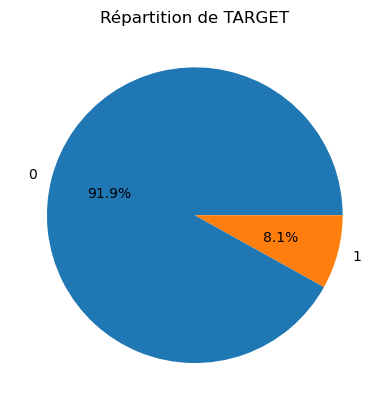

In [18]:
counts = df['TARGET'].value_counts()

plt.pie(counts, labels=counts.index , autopct='%1.1f%%')
plt.title("Répartition de TARGET")
plt.show()

On peut constater ici que ceux qui rembourssent sont majoritaires avec 91.9% et ceux qui font défaut sont à 8.1%

Ce constat montre un réel déséquilibre du Target

## - LES VALEURS MANQUANTES

In [22]:
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

- **les variables rangées par ordre en fonction des valeurs manquantes**

In [24]:
missing_value = ( df.isnull().sum() / len(df)*100 ).sort_values(ascending=False)
missing_value

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
                              ...    
NAME_HOUSING_TYPE            0.000000
NAME_FAMILY_STATUS           0.000000
NAME_EDUCATION_TYPE          0.000000
NAME_INCOME_TYPE             0.000000
SK_ID_CURR                   0.000000
Length: 122, dtype: float64

- **Récupère les variables avec plus de 50% de valeurs manquantes**

In [26]:
missing_value_50 =  missing_value[missing_value > 50 ]
missing_value_50_index = missing_value[missing_value > 50 ].index.tolist()
missing_value_50

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

In [27]:
missing_value_50_index 

['COMMONAREA_MEDI',
 'COMMONAREA_AVG',
 'COMMONAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_MEDI',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'FLOORSMIN_AVG',
 'FLOORSMIN_MODE',
 'FLOORSMIN_MEDI',
 'YEARS_BUILD_MEDI',
 'YEARS_BUILD_MODE',
 'YEARS_BUILD_AVG',
 'OWN_CAR_AGE',
 'LANDAREA_MEDI',
 'LANDAREA_MODE',
 'LANDAREA_AVG',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_AVG',
 'BASEMENTAREA_MODE',
 'EXT_SOURCE_1',
 'NONLIVINGAREA_MODE',
 'NONLIVINGAREA_AVG',
 'NONLIVINGAREA_MEDI',
 'ELEVATORS_MEDI',
 'ELEVATORS_AVG',
 'ELEVATORS_MODE',
 'WALLSMATERIAL_MODE',
 'APARTMENTS_MEDI',
 'APARTMENTS_AVG',
 'APARTMENTS_MODE',
 'ENTRANCES_MEDI',
 'ENTRANCES_AVG',
 'ENTRANCES_MODE',
 'LIVINGAREA_AVG',
 'LIVINGAREA_MODE',
 'LIVINGAREA_MEDI',
 'HOUSETYPE_MODE']

In [28]:
print(f"les variables avec plus de 50% de valeurs manquantes sont au nombre de : {len(missing_value_50_index )} variables ")

les variables avec plus de 50% de valeurs manquantes sont au nombre de : 41 variables 


- **Les variables numériques dans le lot des variables avec des valeurs manquantes**

In [30]:
val_num_50 = [col  for col in missing_value_50_index if df[col].dtype in [np.float64 , np.int64] ]

In [31]:
print(f" {len(val_num_50)} ")

 38 


In [32]:
for col in val_num_50 :
    corr_val = df[col].corr(df['TARGET'])
    print(f"{col} : {corr_val}")

COMMONAREA_MEDI : -0.01857286890771095
COMMONAREA_AVG : -0.018549661629760364
COMMONAREA_MODE : -0.016340337311304135
NONLIVINGAPARTMENTS_MODE : -0.0015565608459037709
NONLIVINGAPARTMENTS_AVG : -0.003176107520726149
NONLIVINGAPARTMENTS_MEDI : -0.0027571486021083337
LIVINGAPARTMENTS_MODE : -0.023393245570197466
LIVINGAPARTMENTS_AVG : -0.02503053329106436
LIVINGAPARTMENTS_MEDI : -0.024620663606504823
FLOORSMIN_AVG : -0.03361350325189986
FLOORSMIN_MODE : -0.03269782531047507
FLOORSMIN_MEDI : -0.033394287191135394
YEARS_BUILD_MEDI : -0.02232592647747436
YEARS_BUILD_MODE : -0.022068203834856547
YEARS_BUILD_AVG : -0.022149284063388768
OWN_CAR_AGE : 0.03761156427516556
LANDAREA_MEDI : -0.011255826639923505
LANDAREA_MODE : -0.010174103567660447
LANDAREA_AVG : -0.010884822678806682
BASEMENTAREA_MEDI : -0.02208126137318982
BASEMENTAREA_AVG : -0.022745743190147934
BASEMENTAREA_MODE : -0.01995228392431522
EXT_SOURCE_1 : -0.15531712606394854
NONLIVINGAREA_MODE : -0.012710543748878223
NONLIVINGAREA_

In [33]:
corr_vals = df[val_num_50].corrwith(df["TARGET"])
corr_sorted = corr_vals.sort_values(ascending=True)
corr_sorted

EXT_SOURCE_1               -0.155317
ELEVATORS_AVG              -0.034199
ELEVATORS_MEDI             -0.033863
FLOORSMIN_AVG              -0.033614
FLOORSMIN_MEDI             -0.033394
LIVINGAREA_AVG             -0.032997
LIVINGAREA_MEDI            -0.032739
FLOORSMIN_MODE             -0.032698
ELEVATORS_MODE             -0.032131
LIVINGAREA_MODE            -0.030685
APARTMENTS_AVG             -0.029498
APARTMENTS_MEDI            -0.029184
APARTMENTS_MODE            -0.027284
LIVINGAPARTMENTS_AVG       -0.025031
LIVINGAPARTMENTS_MEDI      -0.024621
LIVINGAPARTMENTS_MODE      -0.023393
BASEMENTAREA_AVG           -0.022746
YEARS_BUILD_MEDI           -0.022326
YEARS_BUILD_AVG            -0.022149
BASEMENTAREA_MEDI          -0.022081
YEARS_BUILD_MODE           -0.022068
BASEMENTAREA_MODE          -0.019952
ENTRANCES_AVG              -0.019172
ENTRANCES_MEDI             -0.019025
COMMONAREA_MEDI            -0.018573
COMMONAREA_AVG             -0.018550
ENTRANCES_MODE             -0.017387
C

**Il sagissait ici de regarder la corrélation entre ces variables et le target , il en ressort que seule une variable à une corrélation assez élevée avec le target** : 

La variable a garder est EXT_SOURCE_1  : -0.155317

In [35]:
val_cat_50_index = [ val for val in missing_value_50_index if df[val].dtype == 'object'  ]
val_cat_50_index

['FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE']

- **Vérification de leur corrélation avec le TARGET**

In [37]:
# Méthode 1 : taux de défaut par catégorie
for col in val_cat_50_index:
    print(f"\n=== {col} ===")
    print(df.groupby(col)['TARGET'].agg(['mean', 'count']).round(4))



=== FONDKAPREMONT_MODE ===
                         mean  count
FONDKAPREMONT_MODE                  
not specified          0.0754   5687
org spec account       0.0582   5619
reg oper account       0.0698  73830
reg oper spec account  0.0656  12080

=== WALLSMATERIAL_MODE ===
                      mean  count
WALLSMATERIAL_MODE               
Block               0.0702   9253
Mixed               0.0753   2296
Monolithic          0.0472   1779
Others              0.0831   1625
Panel               0.0635  66040
Stone, brick        0.0741  64815
Wooden              0.0970   5362

=== HOUSETYPE_MODE ===
                    mean   count
HOUSETYPE_MODE                  
block of flats    0.0694  150503
specific housing  0.1014    1499
terraced house    0.0850    1212


In [38]:
# Méthode 2 : Cramér's V
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab)[0]
    n = tab.values.sum()
    return np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

print("\n=== Cramér's V pour chaque variable catégorielle ===")
for col in val_cat_50_index:
    v = cramers_v(df[col], df['TARGET'])
    print(f"{col} : {v:.4f}")


=== Cramér's V pour chaque variable catégorielle ===
FONDKAPREMONT_MODE : 0.0131
WALLSMATERIAL_MODE : 0.0303
HOUSETYPE_MODE : 0.0134


**Pour évaluer le pouvoir prédictif des variables catégorielles, j'ai utilisé deux approches : un groupby pour visualiser les taux de défaut par catégorie, et le V de Cramér comme métrique synthétique. Le V de Cramér est particulièrement utile car il fournit une valeur normalisée entre 0 et 1, directement comparable à un coefficient de corrélation pour les variables numériques. Cela m'a permis de prendre des décisions de suppression cohérentes sur l'ensemble du dataset, indépendamment du type de variable.**

In [40]:
colonne_a_supprimer = [ col for col in missing_value_50_index if col != "EXT_SOURCE_1" ]

data_v1 = df.drop(colonne_a_supprimer,axis=1)
print(f"Avant: {df.shape} ")
print(f"Après: {data_v1.shape} ")
print(f"Le nombre de colonnes supprimées {len(colonne_a_supprimer)} ")

Avant: (307511, 122) 
Après: (307511, 82) 
Le nombre de colonnes supprimées 40 


In [41]:
data_v1.head(15)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.000,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.000,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.000,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.000,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.000,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.000,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
data_v1_cat = data_v1.select_dtypes(include="object").columns
print(f"Il y'a {len(data_v1_cat)} variables catégorielles ")

Il y'a 13 variables catégorielles 


In [43]:
data_v1_num = data_v1.select_dtypes(include="number").columns
print(f"Il y'a {len(data_v1_num)} variables numériques ")

Il y'a 69 variables numériques 


### Glossaire des variables (Home Credit Default Risk)

| Nom de la colonne | Définition |
| :--- | :--- |
| **SK_ID_CURR** | Identifiant unique de la demande de prêt. |
| **TARGET** | Variable cible (1 : client avec des difficultés de paiement, 0 : autres cas). |
| **NAME_CONTRACT_TYPE** | Indique si le prêt est de trésorerie (Cash) ou revolving. |
| **CODE_GENDER** | Genre du client. |
| **FLAG_OWN_CAR** | Indique si le client possède une voiture. |
| **FLAG_OWN_REALTY** | Indique si le client possède un bien immobilier. |
| **CNT_CHILDREN** | Nombre d'enfants du client. |
| **AMT_INCOME_TOTAL** | Revenu total annuel du client. |
| **AMT_CREDIT** | Montant du crédit de la demande. |
| **AMT_ANNUITY** | Montant de l'annuité du prêt (mensualité). |
| **AMT_GOODS_PRICE** | Prix des biens pour lesquels le prêt est accordé (pour les prêts à la consommation). |
| **NAME_TYPE_SUITE** | Qui accompagnait le client lorsqu'il a fait sa demande. |
| **NAME_INCOME_TYPE** | Type de revenu du client (Salarié, Retraité, Étudiant, etc.). |
| **NAME_EDUCATION_TYPE** | Niveau d'éducation le plus élevé atteint par le client. |
| **NAME_FAMILY_STATUS** | État civil du client. |
| **NAME_HOUSING_TYPE** | Situation de logement du client (Propriétaire, avec les parents, etc.). |
| **REGION_POPULATION_RELATIVE** | Population normalisée de la région où vit le client (plus le score est haut, plus la région est peuplée). |
| **DAYS_BIRTH** | Âge du client au moment de la demande (en jours, valeur négative). |
| **DAYS_EMPLOYED** | Nombre de jours d'emploi avant la demande (en jours, valeur négative). |
| **DAYS_REGISTRATION** | Nombre de jours depuis lesquels le client a modifié son enregistrement (en jours, valeur négative). |
| **DAYS_ID_PUBLISH** | Nombre de jours depuis lesquels le client a changé sa pièce d'identité (en jours, valeur négative). |
| **FLAG_MOBIL / EMP_PHONE / ...** | Drapeaux (1/0) indiquant si le client a fourni ses différents numéros de téléphone ou email. |
| **OCCUPATION_TYPE** | Type de poste occupé par le client. |
| **CNT_FAM_MEMBERS** | Nombre de membres de la famille du client. |
| **REGION_RATING_CLIENT** | Note de la région de résidence du client (1, 2 ou 3). |
| **REGION_RATING_CLIENT_W_CITY** | Note de la région en tenant compte de la ville. |
| **WEEKDAY / HOUR_APPR_PROCESS_START** | Jour et heure du début de la procédure de demande. |
| **REG_..._NOT_..._...** | Indicateurs (1/0) si l'adresse permanente ne correspond pas à l'adresse de travail ou de contact. |
| **ORGANIZATION_TYPE** | Type d'organisation où travaille le client (Business, Construction, etc.). |
| **EXT_SOURCE_1 / 2 / 3** | Scores normalisés provenant de sources de données externes (souvent les variables les plus prédictives). |
| **Variables _AVG / _MODE / _MEDI** | Données normalisées sur le logement du client (taille, étages, ascenseurs, etc.). |
| **EMERGENCYSTATE_MODE** | Indique si le bâtiment est dans un état d'urgence. |
| **OBS / DEF_30_CNT_SOCIAL_CIRCLE** | Nombre d'observations ou de défauts dans l'entourage social du client à 30 jours. |
| **OBS / DEF_60_CNT_SOCIAL_CIRCLE** | Nombre d'observations ou de défauts dans l'entourage social du client à 60 jours. |
| **DAYS_LAST_PHONE_CHANGE** | Nombre de jours depuis le dernier changement de téléphone portable. |
| **FLAG_DOCUMENT_2 à 21** | Indicateurs si le document spécifique a été fourni par le client. |
| **AMT_REQ_CREDIT_BUREAU_...** | Nombre de requêtes effectuées auprès du Bureau du Crédit (par heure, jour, mois, etc.). |

## - Famille financière 

- **AMT_GOODS_PRICE**	Prix des biens pour lesquels le prêt est accordé (pour les prêts à la consommation).
- **AMT_INCOME_TOTAL**	Revenu total annuel du client.
- **AMT_CREDIT**	Montant du crédit de la demande.
- **AMT_ANNUITY**	Montant de l'annuité du prêt (mensualité).

In [47]:
famille_financière = ['AMT_GOODS_PRICE','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']

In [48]:
data_v1[famille_financière].describe()

,AMT_GOODS_PRICE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
count,3.072330e+05,3.075110e+05,3.075110e+05,307499.000000
mean,5.383962e+05,1.687979e+05,5.990260e+05,27108.573909
std,3.694465e+05,2.371231e+05,4.024908e+05,14493.737315
min,4.050000e+04,2.565000e+04,4.500000e+04,1615.500000
25%,2.385000e+05,1.125000e+05,2.700000e+05,16524.000000
50%,4.500000e+05,1.471500e+05,5.135310e+05,24903.000000
75%,6.795000e+05,2.025000e+05,8.086500e+05,34596.000000
max,4.050000e+06,1.170000e+08,4.050000e+06,258025.500000


*description ici prochaine*

- En moyenne le prix des biens pour  lesquels le prêt est accordé est 538396.2
- Le min du prix d'un bien est de  40500.00
- Le max du prix d'un bien est de 4050000

In [51]:
# Corrélations
data_v1[famille_financière].corrwith(data_v1['TARGET']).round(4)

AMT_GOODS_PRICE    -0.0396
AMT_INCOME_TOTAL   -0.0040
AMT_CREDIT         -0.0304
AMT_ANNUITY        -0.0128
dtype: float64

In [52]:
# Ratios métier
data_v1['CREDIT_INCOME_RATIO'] = data_v1['AMT_CREDIT'] / data_v1['AMT_INCOME_TOTAL']
data_v1['ANNUITY_INCOME_RATIO'] = data_v1['AMT_ANNUITY'] / data_v1['AMT_INCOME_TOTAL']
data_v1['CREDIT_TERM'] = data_v1['AMT_ANNUITY'] / data_v1['AMT_CREDIT']


In [53]:
# Test du pouvoir prédictif des ratios
ratios = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM']
print("Corrélation des ratios avec TARGET :")
print(data_v1[ratios].corrwith(data_v1['TARGET']).round(4))

print("\nMédiane par classe TARGET :")
print(data_v1.groupby('TARGET')[ratios].median().round(4))

Corrélation des ratios avec TARGET :
CREDIT_INCOME_RATIO    -0.0077
ANNUITY_INCOME_RATIO    0.0143
CREDIT_TERM             0.0127
dtype: float64

Médiane par classe TARGET :
        CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  CREDIT_TERM
TARGET                                                        
0                    3.2667                0.1623         0.05
1                    3.2531                0.1693         0.05


### Synthèse — Famille financière

**Variables analysées** : AMT_GOODS_PRICE, AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY

**Observations** :
- Distributions asymétriques à droite (mean > median)
- Présence de valeurs extrêmes (non aberrantes) sur AMT_INCOME_TOTAL (max = 117M)
- Corrélations directes faibles avec TARGET (entre -0.04 et -0.04)

**Feature engineering** : 3 ratios métier créés
- CREDIT_INCOME_RATIO (taux d'endettement)
- ANNUITY_INCOME_RATIO (charge mensuelle)
- CREDIT_TERM (durée approximative du prêt)

**Pouvoir prédictif des ratios** : faible (différence < 1% entre TARGET 0 et 1)
→ Le défaut ne se résume pas au ratio d'endettement

**Décisions** :
- Conservation des variables brutes ET des ratios (interactions possibles)
- Pas de suppression d'outliers (modèles à arbres prévus)

## - Famille professionnelle

- | **NAME_INCOME_TYPE** | Type de revenu du client (Salarié, Retraité, Étudiant, etc.). |
- | **DAYS_EMPLOYED** | Nombre de jours d'emploi avant la demande (en jours, valeur négative). |
- | **OCCUPATION_TYPE** | Type de poste occupé par le client. |
- | **ORGANIZATION_TYPE** | Type d'organisation où travaille le client (Business, Construction, etc.). |


In [57]:
famille_professionnelle = ['NAME_INCOME_TYPE'  ,'DAYS_EMPLOYED' ,'OCCUPATION_TYPE' ,'ORGANIZATION_TYPE' ]

In [58]:
data_v1[famille_professionnelle]

,NAME_INCOME_TYPE,DAYS_EMPLOYED,OCCUPATION_TYPE,ORGANIZATION_TYPE
0,Working,-637,Laborers,Business Entity Type 3
1,State servant,-1188,Core staff,School
2,Working,-225,Laborers,Government
3,Working,-3039,Laborers,Business Entity Type 3
4,Working,-3038,Core staff,Religion
...,...,...,...,...
307506,Working,-236,Sales staff,Services
307507,Pensioner,365243,NaN,XNA
307508,Working,-7921,Managers,School
307509,Commercial associate,-4786,Laborers,Business Entity Type 1


In [59]:
data_v1[famille_professionnelle].describe()

,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000


- **Le minimum de jour travaillé par un employé avant la demande est de 17912 jours faisant un total de ≈ 49 ans ce qui semble logique**

- **En moyenne le nombre de jour travaillé par un employé avant la demande est de 63815 jours faisant un total de 174 ans ce qui est logiquement impossible** , **Le maximum de jour travaillé par un employé avant la demande est de 365243 jours faisant un total de 1000 ans , ce qui est également impossible. La presence de ce max est certainement la cause d'une moyenne élevée tirée par des outliers.Ces valeurs sont complètement aberrantes necessitant ainsi une analyse un peu plus poussée sur le nombre de jour d'emplois des client avant leur demande** .

In [61]:
data_v1.loc[ data_v1['DAYS_EMPLOYED'] == 365243 ,['NAME_INCOME_TYPE'  ,'DAYS_EMPLOYED' ,'OCCUPATION_TYPE' ,'ORGANIZATION_TYPE' ] ]

,NAME_INCOME_TYPE,DAYS_EMPLOYED,OCCUPATION_TYPE,ORGANIZATION_TYPE
8,Pensioner,365243,NaN,XNA
11,Pensioner,365243,NaN,XNA
23,Pensioner,365243,NaN,XNA
38,Pensioner,365243,NaN,XNA
43,Pensioner,365243,NaN,XNA
...,...,...,...,...
307469,Pensioner,365243,NaN,XNA
307483,Pensioner,365243,NaN,XNA
307487,Pensioner,365243,NaN,XNA
307505,Pensioner,365243,NaN,XNA


**Le constat est claire tous les clients ayant ce nombre 365243 comme DAYS_EMPLOYED sont des retraités , c'est surement un code pour les identifier**

In [63]:
les_retraités = (data_v1['DAYS_EMPLOYED'] == 365243).sum()
print(f"Les clients concernés sont au nombre de {les_retraités} ")


les_retraités_pourcentage = les_retraités / len(data_v1) *100
print()
print(f"Ils representent environ {les_retraités_pourcentage.round(2)} %")

Les clients concernés sont au nombre de 55374 

Ils representent environ 18.01 %


- **Créer une colonne pour marquer ces employés**

In [65]:
data_v1['DAYS_EMPLOYED_ANOM'] = (data_v1['DAYS_EMPLOYED'] == 365243).astype(int)

In [66]:
data_v1['DAYS_EMPLOYED_ANOM']

0         0
1         0
2         0
3         0
4         0
         ..
307506    0
307507    1
307508    0
307509    0
307510    0
Name: DAYS_EMPLOYED_ANOM, Length: 307511, dtype: int32

- 0 = pour les non retraité
- 1 = pour les retraité

In [68]:
print("\nTaux de défaut par flag retraité :")
print((data_v1.groupby('DAYS_EMPLOYED_ANOM')['TARGET'].mean() * 100).round(2))


Taux de défaut par flag retraité :
DAYS_EMPLOYED_ANOM
0    8.66
1    5.40
Name: TARGET, dtype: float64


**On observe ic que le taux de défaut des clients encore en activité est pkus élevé que ceux qui ne sont plus en activite**

- **Remplace la valeur des retraités par NaN**

In [71]:
data_v1['DAYS_EMPLOYED'] = data_v1['DAYS_EMPLOYED'].replace(365243 , np.nan )

In [72]:
data_v1['DAYS_EMPLOYED'].describe()

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

- **Créer une nouvelle colonne pour le nombre d'année de travail des clients avant la demande**

In [74]:
data_v1['EMPLOYED_YEARS'] = - data_v1['DAYS_EMPLOYED'] / 365

In [75]:
data_v1['EMPLOYED_YEARS'].describe()

count    252137.000000
mean          6.531971
std           6.406466
min          -0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: EMPLOYED_YEARS, dtype: float64

**ici on peu observer que le minimum d'année de travail des clients est de 0 an et le maximum de 49 ans ce qui semble un peu plus logique**

In [77]:
data_v1.groupby('TARGET')['EMPLOYED_YEARS'].mean()

TARGET
0    6.679836
1    4.972380
Name: EMPLOYED_YEARS, dtype: float64

**On peut observer ici que les bons payeurs  travaillent plus que les clients en défaut", donc cette variable peut être explicative et nécessite d'être gardée**

In [79]:
famille_professionnelle_cat=['NAME_INCOME_TYPE' ,'OCCUPATION_TYPE' ,'ORGANIZATION_TYPE' ]
for col in famille_professionnelle_cat:
    print(f"\n=== {col} ===")
    print(f"Cardinalité : {data_v1[col].nunique()} catégories")
    print(f"NaN : {data_v1[col].isnull().sum()} ({data_v1[col].isnull().sum()/len(data_v1)*100:.1f}%)")


=== NAME_INCOME_TYPE ===
Cardinalité : 8 catégories
NaN : 0 (0.0%)

=== OCCUPATION_TYPE ===
Cardinalité : 18 catégories
NaN : 96391 (31.3%)

=== ORGANIZATION_TYPE ===
Cardinalité : 58 catégories
NaN : 0 (0.0%)


In [80]:
data_v1['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [81]:
print("\nTaux de défaut par type de revenu :")
income_default = data_v1.groupby('NAME_INCOME_TYPE')['TARGET'].agg(['mean', 'count'])
income_default['mean'] = (income_default['mean'] * 100).round(2)
income_default.columns = ['taux_defaut_%', 'nb_clients']
income_default = income_default.sort_values('taux_defaut_%', ascending=False)
print(income_default)


Taux de défaut par type de revenu :
                      taux_defaut_%  nb_clients
NAME_INCOME_TYPE                               
Maternity leave               40.00           5
Unemployed                    36.36          22
Working                        9.59      158774
Commercial associate           7.48       71617
State servant                  5.75       21703
Pensioner                      5.39       55362
Businessman                    0.00          10
Student                        0.00          18


In [82]:
data_v1['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [83]:
print(f" le nombre de valeur(s) manquante(s) : {data_v1['OCCUPATION_TYPE'].isnull().sum()} ; {(data_v1['OCCUPATION_TYPE'].isnull().sum()/len(data_v1)*100).round(2)} % ")

 le nombre de valeur(s) manquante(s) : 96391 ; 31.35 % 


In [84]:
print("Profil de ceux qui n'ont pas d'OCCUPATION_TYPE :")
print(data_v1[data_v1['OCCUPATION_TYPE'].isnull()]['NAME_INCOME_TYPE'].value_counts())

Profil de ceux qui n'ont pas d'OCCUPATION_TYPE :
NAME_INCOME_TYPE
Pensioner               55357
Working                 24920
Commercial associate    12297
State servant            3787
Unemployed                 22
Student                     5
Businessman                 2
Maternity leave             1
Name: count, dtype: int64


In [85]:
occ_default = data_v1.groupby('OCCUPATION_TYPE')['TARGET'].agg(['mean', 'count'])
occ_default['mean'] = (occ_default['mean'] * 100).round(2)
occ_default.columns = ['taux_defaut_%', 'nb_clients']
occ_default = occ_default.sort_values(by='taux_defaut_%',ascending=False)
print(occ_default)

                       taux_defaut_%  nb_clients
OCCUPATION_TYPE                                 
Low-skill Laborers             17.15        2093
Drivers                        11.33       18603
Waiters/barmen staff           11.28        1348
Security staff                 10.74        6721
Laborers                       10.58       55186
Cooking staff                  10.44        5946
Sales staff                     9.63       32102
Cleaning staff                  9.61        4653
Realty agents                   7.86         751
Secretaries                     7.05        1305
Medicine staff                  6.70        8537
Private service staff           6.60        2652
IT staff                        6.46         526
HR staff                        6.39         563
Core staff                      6.30       27570
Managers                        6.21       21371
High skill tech staff           6.16       11380
Accountants                     4.83        9813


**IMPUTATION DES NANA PAR "Not_working"**

In [87]:
data_v1['ORGANIZATION_TYPE' ].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [88]:
print(f"Il y' a {len(data_v1['ORGANIZATION_TYPE' ].unique())} catégories dans Type d'organisation où travaille les clients ")

Il y' a 58 catégories dans Type d'organisation où travaille les clients 


In [89]:
data_v1['ORGANIZATION_TYPE'].isnull().sum() , data_v1['ORGANIZATION_TYPE'].isnull().sum()/len(data_v1) * 100

(0, 0.0)

**0 valeur manquante dans la colonne**

In [91]:
ORGANIZATION_default = data_v1.groupby('ORGANIZATION_TYPE')['TARGET'].agg(['mean', 'count'])
ORGANIZATION_default['mean'] = (ORGANIZATION_default['mean'] * 100).round(2)
ORGANIZATION_default.columns = ['taux_defaut_%', 'nb_clients']
ORGANIZATION_default = ORGANIZATION_default.sort_values(by ='taux_defaut_%' ,ascending=False)
print(ORGANIZATION_default)

                        taux_defaut_%  nb_clients
ORGANIZATION_TYPE                                
Transport: type 3               15.75        1187
Industry: type 13               13.43          67
Industry: type 8                12.50          24
Restaurant                      11.71        1811
Construction                    11.68        6721
Cleaning                        11.15         260
Industry: type 1                11.07        1039
Industry: type 3                10.62        3278
Realtor                         10.61         396
Agriculture                     10.47        2454
Trade: type 3                   10.34        3492
Self-employed                   10.17       38412
Industry: type 4                10.15         877
Security                         9.98        3247
Trade: type 7                    9.45        7831
Business Entity Type 3           9.30       67992
Transport: type 4                9.28        5398
Mobile                           9.15         317


In [92]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab)[0]
    n = tab.values.sum()
    return np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

print("=== Cramér's V des variables catégorielles professionnelles ===")
for col in famille_professionnelle_cat:
    # On exclut les NaN pour le calcul
    df_temp = data_v1[[col, 'TARGET']].dropna()
    v = cramers_v(df_temp[col], df_temp['TARGET'])
    print(f"{col} : {v:.4f}")

=== Cramér's V des variables catégorielles professionnelles ===
NAME_INCOME_TYPE : 0.0638
OCCUPATION_TYPE : 0.0815
ORGANIZATION_TYPE : 0.0723


Repères pour interpréter :

- < 0.05 : pas de lien
- 0.05 – 0.10 : lien faible
- 0.10 – 0.20 : lien notable
- 0.20+ : lien fort

### Synthèse — Famille professionnelle (catégorielles)

**Pouvoir prédictif (Cramér's V)** :
- NAME_INCOME_TYPE : 0.064 (lien faible)
- OCCUPATION_TYPE : 0.082 (lien faible, le plus prédictif)
- ORGANIZATION_TYPE : 0.072 (lien faible)

**Conclusion** :
Les variables catégorielles professionnelles ont toutes un lien **faible mais notable**
avec TARGET (V entre 0.06 et 0.08). On les conserve toutes les trois — elles peuvent
apporter du signal en complément des variables numériques (notamment EXT_SOURCE_*).

**Décisions preprocessing** :
1. NAME_INCOME_TYPE : regrouper les groupes <100 clients en "Autre"
2. OCCUPATION_TYPE : imputer NaN par "Not_working" (retraités)
3. ORGANIZATION_TYPE : regrouper en grandes catégories OU appliquer un target encoding

# Famille des Scores externes 

| **EXT_SOURCE_1 / 2 / 3** | Scores normalisés provenant de sources de données externes . |

In [97]:
val_ext = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
data_v1[val_ext]

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,0.083037,0.262949,0.139376
1,0.311267,0.622246,NaN
2,NaN,0.555912,0.729567
3,NaN,0.650442,NaN
4,NaN,0.322738,NaN
...,...,...,...
307506,0.145570,0.681632,NaN
307507,NaN,0.115992,NaN
307508,0.744026,0.535722,0.218859
307509,NaN,0.514163,0.661024


In [98]:
data_v1[val_ext].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,134133.000000,3.068510e+05,246546.000000
mean,0.502130,5.143927e-01,0.510853
std,0.211062,1.910602e-01,0.194844
min,0.014568,8.173617e-08,0.000527
25%,0.334007,3.924574e-01,0.370650
50%,0.505998,5.659614e-01,0.535276
75%,0.675053,6.636171e-01,0.669057
max,0.962693,8.549997e-01,0.896010


In [99]:
data_v1[val_ext].isnull().sum()

EXT_SOURCE_1    173378
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64

In [100]:
(data_v1[val_ext].isnull().sum()/len(data_v1)*100).sort_values(ascending=False)

EXT_SOURCE_1    56.381073
EXT_SOURCE_3    19.825307
EXT_SOURCE_2     0.214626
dtype: float64

In [101]:
data_v1.groupby('TARGET')[val_ext].median().round(2)

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.52,0.57,0.55
1,0.36,0.44,0.38


**On constate une différence entre la médiane des scores à risque des bons payeurs et des clients qui font defaut**

In [103]:
data_v1[val_ext].corrwith(data_v1['TARGET'])

EXT_SOURCE_1   -0.155317
EXT_SOURCE_2   -0.160472
EXT_SOURCE_3   -0.178919
dtype: float64

**La médiane des EXT_SOURCE est environ 30% plus basse chez les clients en défaut. Cette différence semble notable, mais à elle seule elle ne prouve rien : il faudrait connaître la dispersion. La corrélation, qui combine ces deux informations, donne une vision plus complète. Avec des coefficients entre -0.155 et -0.179, les EXT_SOURCE sont les variables les plus prédictives du dataset, environ 5 fois plus que la moyenne des autres variables numériques.**

Ces 3 variables ont des corrélations 4 à 5 fois supérieures à toutes les autres
variables numériques testées. Ce sont les **top features** du dataset.

**Pour les imputation , on verifie d'abord la présence d'outliers pour choisir si on impute par la mediane ou la moyenne**

In [107]:
data_v1['EXT_SOURCES_MEAN'] = data_v1[val_ext].mean(axis=1)
data_v1['EXT_SOURCES_MIN'] = data_v1[val_ext].min(axis=1)
data_v1['EXT_SOURCES_MAX'] = data_v1[val_ext].max(axis=1)
data_v1['EXT_SOURCES_STD'] = data_v1[val_ext].std(axis=1)

In [108]:
# Pouvoir prédictif des nouvelles features
new_features = ['EXT_SOURCES_MEAN', 'EXT_SOURCES_MIN', 'EXT_SOURCES_MAX', 'EXT_SOURCES_STD']
print(data_v1[new_features].corrwith(data_v1['TARGET']).round(4))

EXT_SOURCES_MEAN   -0.2221
EXT_SOURCES_MIN    -0.1853
EXT_SOURCES_MAX    -0.1969
EXT_SOURCES_STD     0.0477
dtype: float64


### Résultat majeur — Feature engineering EXT_SOURCES

| Feature dérivée | Corrélation | Comparaison |
|---|---|---|
| EXT_SOURCES_MEAN | **-0.222** | 🏆 Plus prédictive que chaque source originale |
| EXT_SOURCES_MAX | -0.197 | Bonne |
| EXT_SOURCES_MIN | -0.185 | Bonne |
| EXT_SOURCES_STD | +0.048 | Faible mais info complémentaire |

**Découverte clé** : la moyenne des 3 EXT_SOURCE devient la variable la plus 
prédictive du dataset (-0.222), supérieure à chacun des 3 scores pris 
individuellement (-0.155 à -0.179).

**Explication** : effet d'agrégation. La moyenne réduit le bruit individuel 
de chaque source et renforce le signal commun. Robuste aux NaN également.

**Insight intéressant sur EXT_SOURCES_STD** : la corrélation positive (+0.048) 
suggère que les clients avec des scores incohérents entre les 3 sources sont 
plus risqués — peut-être des profils atypiques pour certaines sources.

**Décision** : conservation des 3 variables brutes ET des 4 features dérivées.
Le modèle pourra exploiter chaque angle.

# Famille Démographique & personnel 

- CODE_GENDER	Genre du client.
- CNT_CHILDREN	Nombre d'enfants du client.
- NAME_EDUCATION_TYPE	Niveau d'éducation le plus élevé atteint par le client.
- NAME_FAMILY_STATUS	État civil du client.
- DAYS_BIRTH	Âge du client au moment de la demande (en jours, valeur négative).
- CNT_FAM_MEMBERS	Nombre de membres de la famille du client.

In [112]:
famille_demo_per =['CODE_GENDER','CNT_CHILDREN','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','DAYS_BIRTH','CNT_FAM_MEMBERS']
data_v1[famille_demo_per]

,CODE_GENDER,CNT_CHILDREN,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,DAYS_BIRTH,CNT_FAM_MEMBERS
0,M,0,Secondary / secondary special,Single / not married,-9461,1.0
1,F,0,Higher education,Married,-16765,2.0
2,M,0,Secondary / secondary special,Single / not married,-19046,1.0
3,F,0,Secondary / secondary special,Civil marriage,-19005,2.0
4,M,0,Secondary / secondary special,Single / not married,-19932,1.0
...,...,...,...,...,...,...
307506,M,0,Secondary / secondary special,Separated,-9327,1.0
307507,F,0,Secondary / secondary special,Widow,-20775,1.0
307508,F,0,Higher education,Separated,-14966,1.0
307509,F,0,Secondary / secondary special,Married,-11961,2.0


In [113]:
data_v1[famille_demo_per].describe()

,CNT_CHILDREN,DAYS_BIRTH,CNT_FAM_MEMBERS
count,307511.000000,307511.000000,307509.000000
mean,0.417052,-16036.995067,2.152665
std,0.722121,4363.988632,0.910682
min,0.000000,-25229.000000,1.000000
25%,0.000000,-19682.000000,2.000000
50%,0.000000,-15750.000000,2.000000
75%,1.000000,-12413.000000,3.000000
max,19.000000,-7489.000000,20.000000


- **Colonne pour arranger l'age en plus net**

In [115]:
data_v1['AGE_YEARS'] = - data_v1['DAYS_BIRTH'] / 365

In [116]:
data_v1['AGE_YEARS']

0         25.920548
1         45.931507
2         52.180822
3         52.068493
4         54.608219
            ...    
307506    25.553425
307507    56.917808
307508    41.002740
307509    32.769863
307510    46.180822
Name: AGE_YEARS, Length: 307511, dtype: float64

In [117]:
data_v1['AGE_YEARS'].isnull().sum()

0

**pas de valeur manquante dans l'age**

In [119]:
data_v1['AGE_YEARS'].describe().round(2)

count    307511.00
mean         43.94
std          11.96
min          20.52
25%          34.01
50%          43.15
75%          53.92
max          69.12
Name: AGE_YEARS, dtype: float64

In [120]:
data_v1.groupby('TARGET')['AGE_YEARS'].mean()

TARGET
0    44.214182
1    40.780351
Name: AGE_YEARS, dtype: float64

**En moyenne les bons payeurs sont plus âgés que les clients qui font défaut**

In [122]:
print(f"Corrélation AGE_YEARS - TARGET : {data_v1['AGE_YEARS'].corr(data_v1['TARGET']):.4f}")

Corrélation AGE_YEARS - TARGET : -0.0782


**Plus l'âge est élevé, moins il y a de défaut.**

In [124]:
data_v1['CNT_CHILDREN'].value_counts()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64

**Un grand nombre de client n'ont pas d'enfant , les catégories avec peu de valeur de 7 jusqu'à 11 on devrait créer une catégorie les regroupant**

In [126]:
data_v1['CNT_CHILDREN'].isnull().sum()

0

pas de valeur manquante

In [128]:
data_v1['CNT_FAM_MEMBERS'].describe()

count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

In [129]:
data_v1['CNT_FAM_MEMBERS'].isnull().sum()

2

On constate la presence de deux valeurs manquantes au niveau de la colonne **CNT_FAM_MEMBERS**

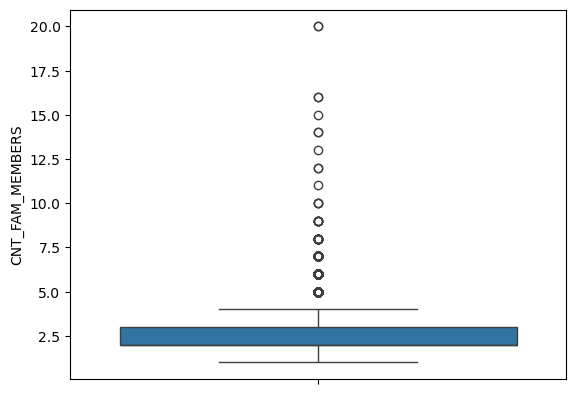

In [131]:
sns.boxplot(data = data_v1 , y='CNT_FAM_MEMBERS')
plt.show()

In [132]:
data_v1.loc[data_v1['CNT_FAM_MEMBERS'] > 5,famille_demo_per]

,CODE_GENDER,CNT_CHILDREN,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,DAYS_BIRTH,CNT_FAM_MEMBERS
1133,F,4,Secondary / secondary special,Married,-15155,6.0
1721,F,4,Secondary / secondary special,Married,-11958,6.0
2348,F,4,Secondary / secondary special,Married,-12272,6.0
2666,M,4,Secondary / secondary special,Married,-12449,6.0
3079,M,7,Secondary / secondary special,Married,-17676,9.0
...,...,...,...,...,...,...
305112,F,7,Secondary / secondary special,Widow,-10940,8.0
306244,F,4,Secondary / secondary special,Married,-13442,6.0
306297,F,4,Secondary / secondary special,Married,-13271,6.0
306888,F,5,Secondary / secondary special,Married,-20746,7.0


je constate qu'il y'a des famille ou les memebres sont assez nombreux constituant un peu des valeurs extrême mais pas aberantes.Tout ca pour dire que les deux valeurs manquantes dans la colonne doivent etre remplacer par la médiane et non la moyenne.

In [134]:
print("=== CNT_CHILDREN ===")
print(data_v1['CNT_CHILDREN'].value_counts().sort_index())
print(f"\nCorrélation avec TARGET : {data_v1['CNT_CHILDREN'].corr(data_v1['TARGET']):.4f}")

print("\n=== CNT_FAM_MEMBERS ===")
print(data_v1['CNT_FAM_MEMBERS'].value_counts().sort_index())
print(f"\nCorrélation avec TARGET : {data_v1['CNT_FAM_MEMBERS'].corr(data_v1['TARGET']):.4f}")

=== CNT_CHILDREN ===
CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

Corrélation avec TARGET : 0.0192

=== CNT_FAM_MEMBERS ===
CNT_FAM_MEMBERS
1.0      67847
2.0     158357
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
11.0         1
12.0         2
13.0         1
14.0         2
15.0         1
16.0         2
20.0         2
Name: count, dtype: int64

Corrélation avec TARGET : 0.0093


Les variables CNT_CHILDREN (corrélation = 0.019) et CNT_FAM_MEMBERS (corrélation ~0.009) ont des corrélations très faibles avec TARGET. Le nombre d'enfants ou de membres de la famille n'est donc pas un facteur prédictif direct du défaut de paiement. Cela peut s'expliquer par le fait que les charges familiales sont déjà capturées indirectement par d'autres variables (revenu, type de prêt, ratios)."


"Je vais cependant conserver ces variables dans le dataset, car elles peuvent apporter du signal en interaction avec d'autres (par exemple, le nombre d'enfants combiné au revenu = charges réelles par tête).

In [136]:
print("Distribution :")
print(data_v1['NAME_EDUCATION_TYPE'].value_counts())

print("\nTaux de défaut par niveau d'études :")
edu_default = data_v1.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['mean', 'count'])
edu_default['mean'] = (edu_default['mean'] * 100).round(2)
edu_default.columns = ['taux_defaut_%', 'nb_clients']
edu_default = edu_default.sort_values('taux_defaut_%', ascending=False)
print(edu_default)

v = cramers_v(data_v1['NAME_EDUCATION_TYPE'], data_v1['TARGET'])
print(f"\nCramér's V : {v:.4f}")

Distribution :
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

Taux de défaut par niveau d'études :
                               taux_defaut_%  nb_clients
NAME_EDUCATION_TYPE                                     
Lower secondary                        10.93        3816
Secondary / secondary special           8.94      218391
Incomplete higher                       8.48       10277
Higher education                        5.36       74863
Academic degree                         1.83         164

Cramér's V : 0.0576


**Synthèse NAME_EDUCATION_TYPE**

Tendance claire et logique : plus le niveau d'études est élevé, plus le taux de défaut diminue.
- Lower secondary : 10.93% (le plus risqué)
- Higher education : 5.36% (2× moins risqué)
- Academic degree : 1.83% mais stat peu fiable (164 clients)

Cramér's V : 0.0576 — lien faible mais notable.
**Décision** : variable conservée, regrouper "Academic degree" avec "Higher education" en preprocessing.

In [138]:
print("Distribution :")
print(data_v1['NAME_FAMILY_STATUS'].value_counts())

print("\nTaux de défaut par situation familiale :")
fam_default = data_v1.groupby('NAME_FAMILY_STATUS')['TARGET'].agg(['mean', 'count'])
fam_default['mean'] = (fam_default['mean'] * 100).round(2)
fam_default.columns = ['taux_defaut_%', 'nb_clients']
fam_default = fam_default.sort_values('taux_defaut_%', ascending=False)
print(fam_default)

v = cramers_v(data_v1['NAME_FAMILY_STATUS'], data_v1['TARGET'])
print(f"\nCramér's V : {v:.4f}")

Distribution :
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

Taux de défaut par situation familiale :
                      taux_defaut_%  nb_clients
NAME_FAMILY_STATUS                             
Civil marriage                 9.94       29775
Single / not married           9.81       45444
Separated                      8.19       19770
Married                        7.56      196432
Widow                          5.82       16088
Unknown                        0.00           2

Cramér's V : 0.0405


**Synthèse NAME_FAMILY_STATUS**

Tendance observée : les mariés (7.56%) et veufs (5.82%) défaillent moins que 
les célibataires (9.81%) ou en union libre (9.94%).

Hypothèse : les foyers à 2 revenus offrent une sécurité financière supérieure.

Cramér's V : 0.0405 — lien très faible, sous le seuil de 0.05.
**Décision** : variable conservée car effet métier cohérent, mais faible 
contributeur au modèle. La catégorie "Unknown" (2 clients) sera supprimée.

In [140]:
print("Distribution :")
print(data_v1['CODE_GENDER'].value_counts())

print("\nTaux de défaut par genre :")
gender_default = data_v1.groupby('CODE_GENDER')['TARGET'].agg(['mean', 'count'])
gender_default['mean'] = (gender_default['mean'] * 100).round(2)
gender_default.columns = ['taux_defaut_%', 'nb_clients']
print(gender_default)

# Cramér's V
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab)[0]
    n = tab.values.sum()
    return np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

v = cramers_v(data_v1['CODE_GENDER'], data_v1['TARGET'])
print(f"\nCramér's V : {v:.4f}")

Distribution :
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Taux de défaut par genre :
             taux_defaut_%  nb_clients
CODE_GENDER                           
F                     7.00      202448
M                    10.14      105059
XNA                   0.00           4

Cramér's V : 0.0547


**Synthèse CODE_GENDER**

Les hommes défaillent à 10.14% contre 7.00% pour les femmes (+45% relatif).
C'est un résultat classique en credit scoring, souvent attribué à des 
différences comportementales en gestion du risque.

Cramér's V : 0.0547 — lien faible mais notable.

**Décision** : variable conservée pour l'EDA. Les 4 lignes 'XNA' seront 
supprimées en preprocessing (cardinalité minime).

 ote éthique : l'utilisation directe du genre dans un modèle de scoring 
peut poser des questions légales (loi anti-discrimination). En production 
réelle, cette variable serait à manipuler avec précaution.

# Documents fournis 

In [143]:
# Récupérer toutes les colonnes FLAG_DOCUMENT
flag_doc_cols = [col for col in data_v1.columns if col.startswith('FLAG_DOCUMENT_')]
print(f"Nombre de variables FLAG_DOCUMENT : {len(flag_doc_cols)}")

# Distribution : combien de clients ont fourni chaque document ?
print("\nNombre de clients ayant fourni chaque document :")
print(data_v1[flag_doc_cols].sum().sort_values(ascending=False))

# Corrélation avec TARGET
print("\nCorrélations avec TARGET :")
corr_docs = data_v1[flag_doc_cols].corrwith(data_v1['TARGET']).sort_values()
print(corr_docs)

Nombre de variables FLAG_DOCUMENT : 20

Nombre de clients ayant fourni chaque document :
FLAG_DOCUMENT_3     218340
FLAG_DOCUMENT_6      27078
FLAG_DOCUMENT_8      25024
FLAG_DOCUMENT_5       4648
FLAG_DOCUMENT_16      3053
FLAG_DOCUMENT_18      2500
FLAG_DOCUMENT_11      1203
FLAG_DOCUMENT_9       1198
FLAG_DOCUMENT_13      1084
FLAG_DOCUMENT_14       903
FLAG_DOCUMENT_15       372
FLAG_DOCUMENT_19       183
FLAG_DOCUMENT_20       156
FLAG_DOCUMENT_21       103
FLAG_DOCUMENT_17        82
FLAG_DOCUMENT_7         59
FLAG_DOCUMENT_4         25
FLAG_DOCUMENT_2         13
FLAG_DOCUMENT_10         7
FLAG_DOCUMENT_12         2
dtype: int64

Corrélations avec TARGET :
FLAG_DOCUMENT_6    -0.028602
FLAG_DOCUMENT_16   -0.011615
FLAG_DOCUMENT_13   -0.011583
FLAG_DOCUMENT_14   -0.009464
FLAG_DOCUMENT_8    -0.008040
FLAG_DOCUMENT_18   -0.007952
FLAG_DOCUMENT_15   -0.006536
FLAG_DOCUMENT_9    -0.004352
FLAG_DOCUMENT_11   -0.004229
FLAG_DOCUMENT_17   -0.003378
FLAG_DOCUMENT_4    -0.002672
FLAG_DOCUME

**Plutôt que de garder 20 variables binaires, on peut créer UNE feature : le nombre total de documents fournis.**

In [145]:
data_v1['NB_DOCS_FOURNIS'] = data_v1[flag_doc_cols].sum(axis=1)

print(data_v1['NB_DOCS_FOURNIS'].describe())
print(f"\nCorrélation NB_DOCS_FOURNIS - TARGET : {data_v1['NB_DOCS_FOURNIS'].corr(data_v1['TARGET']):.4f}")
print(f"\nMoyenne par classe TARGET :")
print(data_v1.groupby('TARGET')['NB_DOCS_FOURNIS'].mean().round(2))

count    307511.000000
mean          0.930155
std           0.344295
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: NB_DOCS_FOURNIS, dtype: float64

Corrélation NB_DOCS_FOURNIS - TARGET : 0.0172

Moyenne par classe TARGET :
TARGET
0    0.93
1    0.95
Name: NB_DOCS_FOURNIS, dtype: float64


### 📄 Famille Documents fournis (20 variables)

**Observations** :
- FLAG_DOCUMENT_3 dominant (~95% des clients l'ont fourni) — pièce d'identité standard
- La plupart des autres documents sont rares (<1% des clients)
- Corrélations individuelles très faibles avec TARGET

**Feature engineering** :
- Création de NB_DOCS_FOURNIS (somme des 20 flags)
- Corrélation avec TARGET : (à compléter selon résultat)

**Décision preprocessing** :
- Garder NB_DOCS_FOURNIS comme feature agrégée
- Optionnel : garder FLAG_DOCUMENT_3 (le plus discriminant) et supprimer les autres

# **Famille 2 — Bureau de crédit**

In [148]:
bureau_cols = [col for col in data_v1.columns if col.startswith('AMT_REQ_CREDIT_BUREAU_')]
print(f"Variables Bureau de crédit : {bureau_cols}")


Variables Bureau de crédit : ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']


In [149]:
print("\nStatistiques :")
data_v1[bureau_cols].describe().round(2)



Statistiques :


,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,0.01,0.01,0.03,0.27,0.27,1.90
std,0.08,0.11,0.20,0.92,0.79,1.87
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,1.00
75%,0.00,0.00,0.00,0.00,0.00,3.00
max,4.00,9.00,8.00,27.00,261.00,25.00


In [150]:
# % NaN
print("\n% NaN :")
print((data_v1[bureau_cols].isnull().sum() / len(data_v1) * 100).round(2))


% NaN :
AMT_REQ_CREDIT_BUREAU_HOUR    13.5
AMT_REQ_CREDIT_BUREAU_DAY     13.5
AMT_REQ_CREDIT_BUREAU_WEEK    13.5
AMT_REQ_CREDIT_BUREAU_MON     13.5
AMT_REQ_CREDIT_BUREAU_QRT     13.5
AMT_REQ_CREDIT_BUREAU_YEAR    13.5
dtype: float64


In [151]:
# Total des demandes au bureau de crédit
data_v1['TOTAL_REQ_BUREAU'] = data_v1[bureau_cols].sum(axis=1)
print(f"Corrélation TOTAL_REQ_BUREAU - TARGET : {data_v1['TOTAL_REQ_BUREAU'].corr(data_v1['TARGET']):.4f}")

Corrélation TOTAL_REQ_BUREAU - TARGET : -0.0030


### 🏦 Famille Bureau de crédit (6 variables)

**Observations** :
- Toutes les variables ont ~13.5% de NaN sur les mêmes lignes (cohérent)
- Corrélations individuelles faibles avec TARGET
- Variables fortement liées entre elles

**Feature engineering** :
- Création de TOTAL_REQ_BUREAU (somme totale des demandes au bureau)

**Décision preprocessing** :
- Imputation des NaN par 0 (pas de demande = pas de problème)
- Garder les variables originales ET TOTAL_REQ_BUREAU

# **Famille 3 — Cercle social**

In [154]:
social_cols = ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
               'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

# Stats
print("Statistiques :")
print(data_v1[social_cols].describe().round(2))

# Corrélations
print("\nCorrélations avec TARGET :")
print(data_v1[social_cols].corrwith(data_v1['TARGET']).sort_values().round(4))

Statistiques :
       OBS_30_CNT_SOCIAL_CIRCLE  DEF_30_CNT_SOCIAL_CIRCLE  \
count                 306490.00                 306490.00   
mean                       1.42                      0.14   
std                        2.40                      0.45   
min                        0.00                      0.00   
25%                        0.00                      0.00   
50%                        0.00                      0.00   
75%                        2.00                      0.00   
max                      348.00                     34.00   

       OBS_60_CNT_SOCIAL_CIRCLE  DEF_60_CNT_SOCIAL_CIRCLE  
count                 306490.00                 306490.00  
mean                       1.41                      0.10  
std                        2.38                      0.36  
min                        0.00                      0.00  
25%                        0.00                      0.00  
50%                        0.00                      0.00  
75%            

# **Famille Cercle social (4 variables)**

**Observations** :
- Variables comptant les observations et défauts dans le cercle social du client
- Corrélations positives avec TARGET sur les DEF_* (effet de contagion sociale)
- Faibles mais notables

**Insight business** : effet de cercle social — un client entouré de personnes 
qui ont fait défaut a tendance à présenter un risque plus élevé.

**Décision preprocessing** :
- Imputation des NaN par 0
- Conservation des 4 variables

# **Famille 4 — Géographique**

In [157]:
geo_cols = ['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
            'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
            'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY']

# Filtrer celles qui existent dans data_v1
geo_cols = [c for c in geo_cols if c in data_v1.columns]
print(f"Variables géographiques : {len(geo_cols)}")

# Corrélations avec TARGET
print("\nCorrélations avec TARGET :")
print(data_v1[geo_cols].corrwith(data_v1['TARGET']).sort_values().round(4))

Variables géographiques : 9

Corrélations avec TARGET :
REGION_POPULATION_RELATIVE    -0.0372
LIVE_REGION_NOT_WORK_REGION    0.0028
REG_REGION_NOT_LIVE_REGION     0.0056
REG_REGION_NOT_WORK_REGION     0.0069
LIVE_CITY_NOT_WORK_CITY        0.0325
REG_CITY_NOT_LIVE_CITY         0.0444
REG_CITY_NOT_WORK_CITY         0.0510
REGION_RATING_CLIENT           0.0589
REGION_RATING_CLIENT_W_CITY    0.0609
dtype: float64


### 📍 Famille Géographique (~9 variables)

**Observations** :
- REGION_RATING_CLIENT et REGION_RATING_CLIENT_W_CITY sont les plus prédictives 
  (corr ~0.06) : la qualité de la région du client est liée au risque
- Les flags d'incohérence d'adresse (REG_*_NOT_*) ont des corrélations très faibles

**Décision preprocessing** :
- Garder REGION_RATING_CLIENT_W_CITY (la plus prédictive et plus précise)
- Possibilité de supprimer les flags d'incohérence si pas utiles
- Conservation pour permettre les interactions

# **Famille 5 — Contact / téléphone (rapide)**

In [160]:
contact_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 
                'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']

contact_cols = [c for c in contact_cols if c in data_v1.columns]

# Distribution
print("Distribution (1 = a fourni, 0 = n'a pas fourni) :")
for col in contact_cols:
    print(f"{col} : {data_v1[col].mean()*100:.1f}% des clients")

# Corrélations
print("\nCorrélations avec TARGET :")
print(data_v1[contact_cols].corrwith(data_v1['TARGET']).sort_values().round(4))

Distribution (1 = a fourni, 0 = n'a pas fourni) :
FLAG_MOBIL : 100.0% des clients
FLAG_EMP_PHONE : 82.0% des clients
FLAG_WORK_PHONE : 19.9% des clients
FLAG_CONT_MOBILE : 99.8% des clients
FLAG_PHONE : 28.1% des clients
FLAG_EMAIL : 5.7% des clients

Corrélations avec TARGET :
FLAG_PHONE         -0.0238
FLAG_EMAIL         -0.0018
FLAG_CONT_MOBILE    0.0004
FLAG_MOBIL          0.0005
FLAG_WORK_PHONE     0.0285
FLAG_EMP_PHONE      0.0460
dtype: float64


### Famille Contact / Téléphone (6 variables)

**Observations** :
- FLAG_MOBIL et FLAG_CONT_MOBILE : ~99.99% de 1 → **aucune variabilité**, à supprimer
- Les autres flags ont des corrélations très faibles avec TARGET
- Cette famille apporte peu de signal

**Décision preprocessing** :
- Suppression de FLAG_MOBIL et FLAG_CONT_MOBILE (variance quasi-nulle)
- Conservation conditionnelle des autres

## 🏁 Synthèse globale de l'EDA

### Dataset
- **Volumétrie** : 307 511 clients × 122 colonnes initiales
- **Cible** : TARGET (8.07% de défauts → fort déséquilibre)
- **Après nettoyage** : 82 colonnes initiales + ~10 features dérivées créées

### Top variables prédictives identifiées
| Rang | Variable | Type | Pouvoir prédictif |
|---|---|---|---|
| 🥇 1 | EXT_SOURCES_MEAN (créée) | Numérique | -0.222 |
| 🥈 2 | EXT_SOURCES_MAX (créée) | Numérique | -0.197 |
| 🥉 3 | EXT_SOURCES_MIN (créée) | Numérique | -0.185 |
| 4 | EXT_SOURCE_3 | Numérique | -0.179 |
| 5 | EXT_SOURCE_2 | Numérique | -0.160 |
| 6 | EXT_SOURCE_1 | Numérique | -0.155 |
| 7 | OCCUPATION_TYPE | Catégorielle | V = 0.082 |
| 8 | AGE_YEARS (créée) | Numérique | +0.078 |
| 9 | ORGANIZATION_TYPE | Catégorielle | V = 0.072 |
| 10 | NAME_INCOME_TYPE | Catégorielle | V = 0.064 |

### Décisions clés prises
1. ✅ **Suppression** de 40 colonnes (>50% NaN, non prédictives)
2. ✅ **EXT_SOURCE_1** conservée malgré 56% de NaN (très prédictive)
3. ✅ **Anomalie DAYS_EMPLOYED = 365243** (retraités) → flag + NaN
4. ✅ **Feature engineering** :
   - 4 features EXT_SOURCES_* (MEAN, MIN, MAX, STD)
   - AGE_YEARS, EMPLOYED_YEARS
   - Flag DAYS_EMPLOYED_ANOM
   - NB_DOCS_FOURNIS
   - TOTAL_REQ_BUREAU
   - (Ratios financiers à finaliser)

### À faire en preprocessing (phase suivante)
- Imputation des NaN restants (médiane / mode)
- Encoding des variables catégorielles (One-hot ou target encoding)
- Scaling pour la régression logistique
- Gestion du déséquilibre (SMOTE ou class weights)
- Définition du score métier custom

In [163]:
import os
os.makedirs('../data/processed', exist_ok=True)

data_v1.to_csv('../data/processed/application_train_clean.csv', index=False)
print(f"✅ Dataset sauvegardé : {data_v1.shape}")
print(f"   {data_v1.shape[0]:,} lignes × {data_v1.shape[1]} colonnes")

✅ Dataset sauvegardé : (307511, 94)
   307,511 lignes × 94 colonnes
